C:\Users\utente\AppData\Local\Temp\ipykernel_21244\1709333728.py:187: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right", frameon=False)


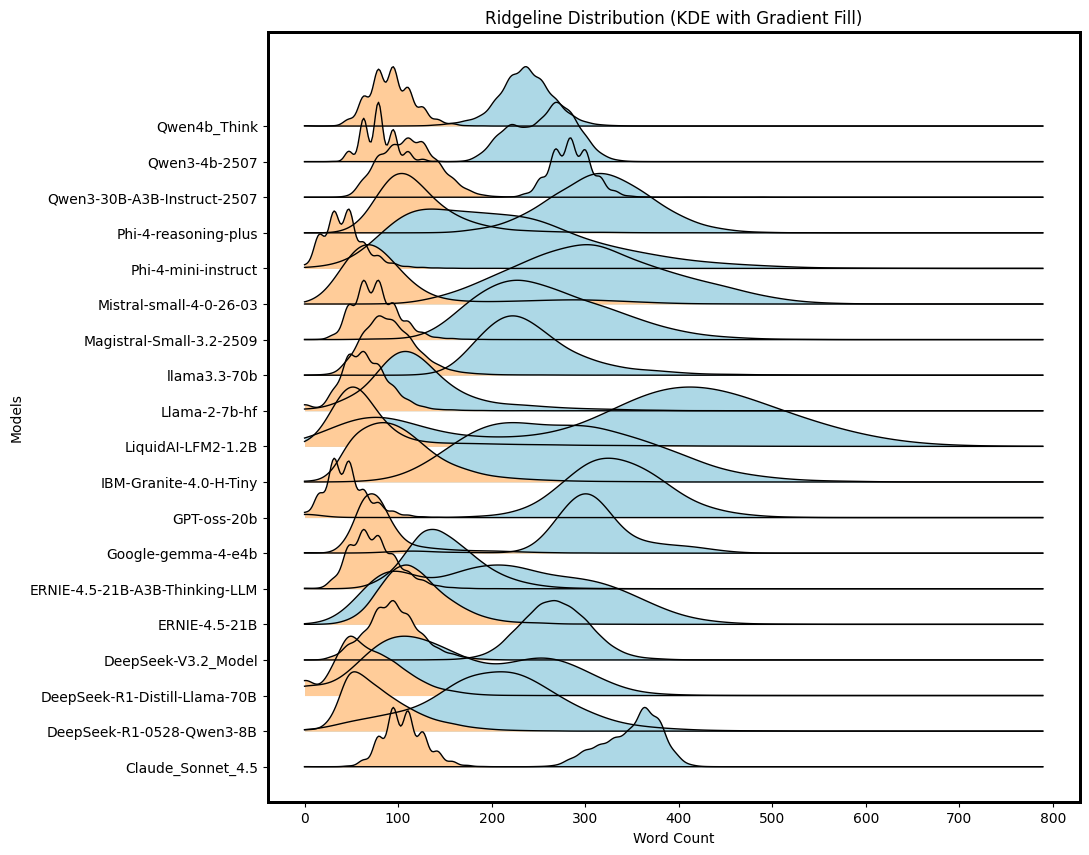

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["patch.antialiased"] = False
plt.rcParams["path.simplify"] = False
# =========================
# CONFIGURATION
# =========================
ROOT_DIR = r"C:\Users\utente\Documents\UniTrento\ConvinceMe\Repo\ConvinceMe\ProcessedData_ConstraintsFixes\Data_visualization"
OUTPUT_DIR = "heatmaps_output"
BINS = 50  # number of histogram bins

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# COLLECT CSV FILES
# =========================
csv_files = []

for root, _, files in os.walk(ROOT_DIR):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

if not csv_files:
    raise RuntimeError("No CSV files found.")

# =========================
# STORAGE
# =========================
opinion_histograms = []
reasoning_histograms = []
file_labels = []

# =========================
# GLOBAL BIN EDGES
# =========================
all_opinion = []
all_reasoning = []

for path in csv_files:
    df = pd.read_csv(path)
    if "opinion_word_count" in df.columns:
        all_opinion.extend(df["opinion_word_count"].dropna())
    if "reasoning_summary_word_count" in df.columns:
        all_reasoning.extend(df["reasoning_summary_word_count"].dropna())

opinion_bins = np.histogram_bin_edges(all_opinion, bins=BINS)
reasoning_bins = opinion_bins

# =========================
# BUILD HISTOGRAMS
# =========================
for path in csv_files:
    df = pd.read_csv(path)
    label = os.path.basename(os.path.dirname(path))

    # Opinion
    if "opinion_word_count" in df.columns:
        hist, _ = np.histogram(
            df["opinion_word_count"].dropna(),
            bins=opinion_bins
        )
    else:
        hist = np.zeros(BINS)

    # Reasoning
    if "reasoning_summary_word_count" in df.columns:
        hist_r, _ = np.histogram(
            df["reasoning_summary_word_count"].dropna(),
            bins=reasoning_bins
        )
    else:
        hist_r = np.zeros(BINS)

    opinion_histograms.append(hist)
    reasoning_histograms.append(hist_r)
    file_labels.append(label)

# =========================
# CONVERT TO DATAFRAMES
# =========================

opinion_df = pd.DataFrame(
    opinion_histograms,
    index=file_labels
)

reasoning_df = pd.DataFrame(
    reasoning_histograms,
    index=file_labels
)



# REQUIRED
x_bins = opinion_bins[:-1]

fig, ax = plt.subplots(figsize=(14, 10))

SPACING = 0.6
HEIGHT_SCALE = 1.0
cmap = plt.cm.plasma

x_bins_op = np.arange(opinion_df.shape[1])
x_bins_rs = np.arange(reasoning_df.shape[1])

for i, model in reversed(list(enumerate(opinion_df.index))):

    base = i * SPACING

    # =========================
    # OPINION
    # =========================
    counts_op = opinion_df.loc[model].values

    if counts_op.sum() > 0:
        samples_op = np.repeat(x_bins, counts_op.astype(int))

        kde_op = gaussian_kde(samples_op, bw_method=0.25)
        x_smooth = np.linspace(opinion_bins[0], opinion_bins[-1], 500)
        y_op = kde_op(x_smooth)
        y_op = y_op / y_op.max() * HEIGHT_SCALE

        ax.fill_between(
            x_smooth,
            base,
            base + y_op,
            color="lightblue",
            linewidth=0
        )

        ax.plot(
            x_smooth,
            base + y_op,
            color="black",
            linewidth=1
        )

    # =========================
    # REASONING SUMMARY
    # =========================
    counts_rs = reasoning_df.loc[model].values

    if counts_rs.sum() > 0:
        samples_rs = np.repeat(x_bins, counts_rs.astype(int))

        kde_rs = gaussian_kde(samples_rs, bw_method=0.25)
        y_rs = kde_rs(x_smooth)
        y_rs = y_rs / y_rs.max() * HEIGHT_SCALE

        ax.fill_between(
            x_smooth,
            base,
            base + y_rs,
            color="#ffcc99",   # light orange
            linewidth=0
        )

        ax.plot(
            x_smooth,
            base + y_rs,
            color="black",
            linewidth=1
        )



    # Outline
    # ax.plot(x_smooth, base + y_smooth, color="black", linewidth=1)


ax.set_yticks(np.arange(len(opinion_df.index)) * SPACING)
ax.set_yticklabels(opinion_df.index)

ax.set_xlabel("Word Count")
ax.set_ylabel("Models")
ax.set_title("Ridgeline Distribution (KDE with Gradient Fill)")

ax.legend(loc="upper right", frameon=False)

plt.subplots_adjust(left=0.3, right=0.88)
plt.show()

